# Clasificación automatizada del sentimiento en reseñas de IMDb

## Contexto de negocio

Film Junky Union necesita identificar automáticamente reseñas negativas y positivas dentro de su comunidad cinematográfica. Una clasificación consistente permite organizar grandes volúmenes de opiniones, detectar señales de insatisfacción y priorizar el análisis de la experiencia de los usuarios.

## Objetivo analítico

Desarrollar y comparar modelos de procesamiento de lenguaje natural capaces de clasificar el sentimiento de reseñas de películas a partir de texto libre.

## Criterio de éxito

El modelo seleccionado debe alcanzar un valor F1 mínimo de 0.85 en el conjunto de prueba. Esta métrica equilibra precisión y exhaustividad, por lo que resulta adecuada cuando es importante controlar tanto los falsos positivos como los falsos negativos.

## Enfoque

- Validación de la calidad y distribución de los datos.
- Normalización y representación del texto mediante TF-IDF.
- Comparación con una línea base y modelos de regresión logística y LightGBM.
- Evaluación mediante Accuracy, F1, Average Precision y ROC AUC.
- Selección de una alternativa considerando rendimiento, estabilidad y eficiencia operativa.


## Configuración del entorno

Se importan las bibliotecas necesarias para manipulación de datos, visualización, procesamiento de texto y modelado. Para ejecutar el flujo completo, el entorno debe incluir NLTK, spaCy, LightGBM y el modelo de idioma inglés `en_core_web_sm`.

Si el modelo de spaCy no está instalado, puede incorporarse desde la terminal de VS Code con:

```bash
python -m spacy download en_core_web_sm
```


In [1]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


Se configura la visualización integrada del notebook y un estilo consistente para los gráficos.


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'

sns.set_theme(style='whitegrid')


Se habilita la barra de progreso para operaciones sobre DataFrames y se descargan los recursos lingüísticos requeridos por NLTK.


In [3]:
tqdm.pandas()

_ = nltk.download('stopwords', quiet=True)


## Carga y validación de datos

La fuente se carga mediante una ruta relativa para mantener la privacidad de la estructura local y facilitar la portabilidad del repositorio.


In [4]:
df_reviews = pd.read_csv('../../1data_local/data_imdb_review_sentiment_classification/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})


Se revisan dimensiones, estructura, tipos de datos, valores ausentes, duplicados, distribución de la variable objetivo y separación entre entrenamiento y prueba.


In [5]:
print("Dimensiones del dataset (filas, columnas):", df_reviews.shape)
print("\nPrimeras 5 filas:")
display(df_reviews.head())

print("\nInformación general del DataFrame:")
df_reviews.info()

print("\nNúmero de valores nulos por columna:")
print(df_reviews.isna().sum())

num_duplicados = df_reviews.duplicated().sum()
print(f"\nNúmero de filas duplicadas: {num_duplicados}")

print("\nTipos de datos por columna:")
print(df_reviews.dtypes)

if 'pos' in df_reviews.columns:
    print("\nDistribución de la variable objetivo 'pos':")
    print(df_reviews['pos'].value_counts(dropna=False))

if 'ds_part' in df_reviews.columns:
    print("\nDistribución de 'ds_part' (train/test):")
    print(df_reviews['ds_part'].value_counts(dropna=False))


Dimensiones del dataset (filas, columnas): (47331, 17)

Primeras 5 filas:


,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281



Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331

### Diagnóstico inicial

La fuente contiene 47,331 registros y 17 variables. No existen filas duplicadas ni valores ausentes en `review`, la característica principal para el análisis de sentimiento. Las variables `average_rating` y `votes` presentan dos valores ausentes cada una, pero no intervienen en el entrenamiento de los modelos textuales.

La variable objetivo `pos` está prácticamente equilibrada y la partición `ds_part` proporciona conjuntos diferenciados de entrenamiento y prueba. Por tanto, no se requieren técnicas de rebalanceo antes del modelado.


## Análisis exploratorio

### Evolución temporal de películas y reseñas

Se analiza la cantidad de títulos y reseñas por año, junto con la polaridad de las opiniones y el promedio móvil de reseñas por película.


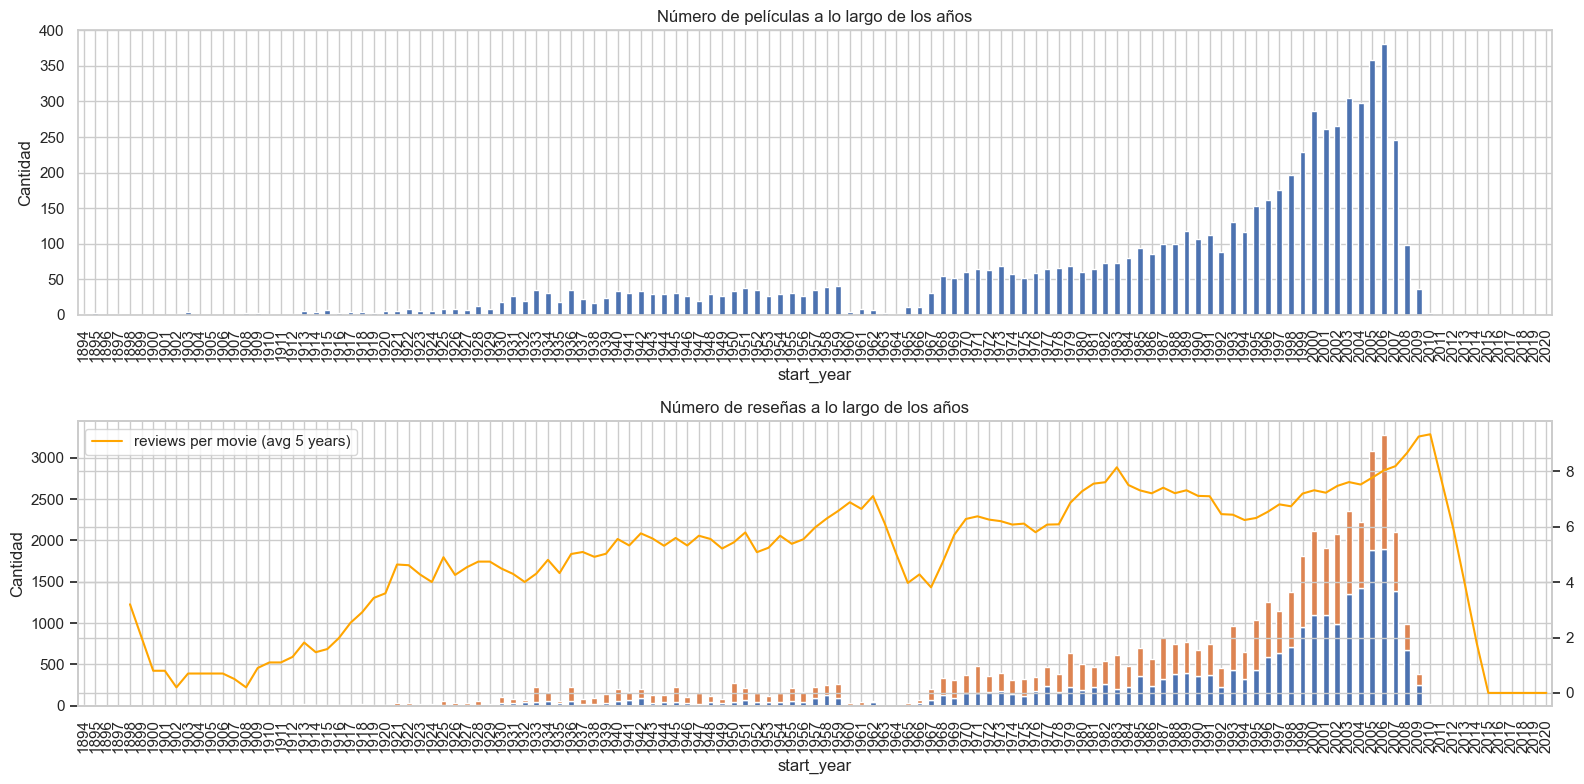

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = (
    df_reviews[['tconst', 'start_year']]
    .drop_duplicates()['start_year']
    .value_counts()
    .sort_index()
)

dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Número de películas a lo largo de los años')
ax.set_ylabel('Cantidad')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, ax=ax, label=['neg', 'pos'])
ax.set_title('Número de reseñas a lo largo de los años')
ax.set_ylabel('Cantidad')

dft_total_reviews = df_reviews['start_year'].value_counts().sort_index()
dft_total_reviews = dft_total_reviews.reindex(index=np.arange(dft_total_reviews.index.min(),
                                                             max(dft_total_reviews.index.max(), 2021))).fillna(0)

dft_reviews_per_movie = (dft_total_reviews / dft1).fillna(0)
axt = ax.twinx()
dft_reviews_per_movie.reset_index(drop=True).rolling(5).mean().plot(color='orange',
                                                                    label='reviews per movie (avg 5 years)',
                                                                    ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

fig.tight_layout()


### Distribución de reseñas, puntuaciones y polaridad

Las siguientes visualizaciones permiten comparar la concentración de reseñas por película, la distribución de puntuaciones entre entrenamiento y prueba, y la estabilidad de las clases a lo largo del tiempo.


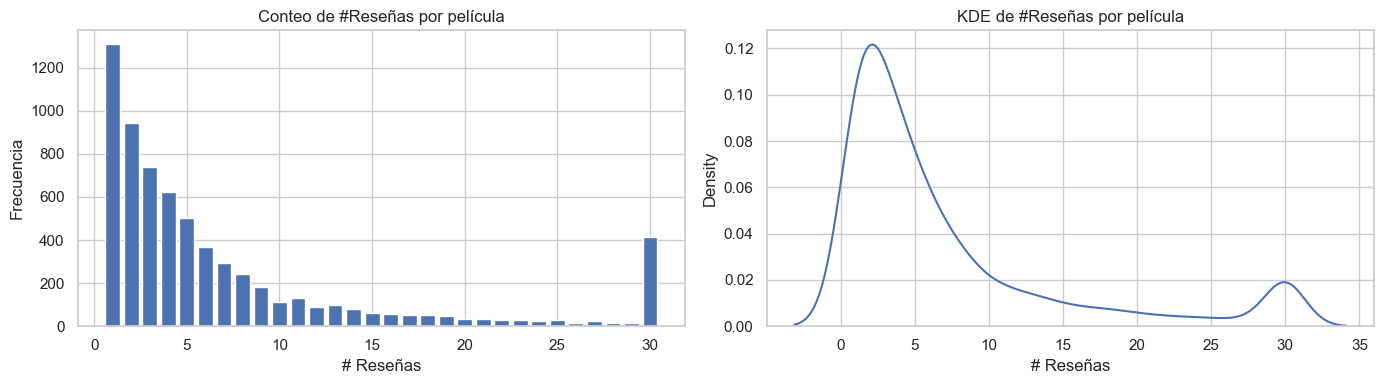

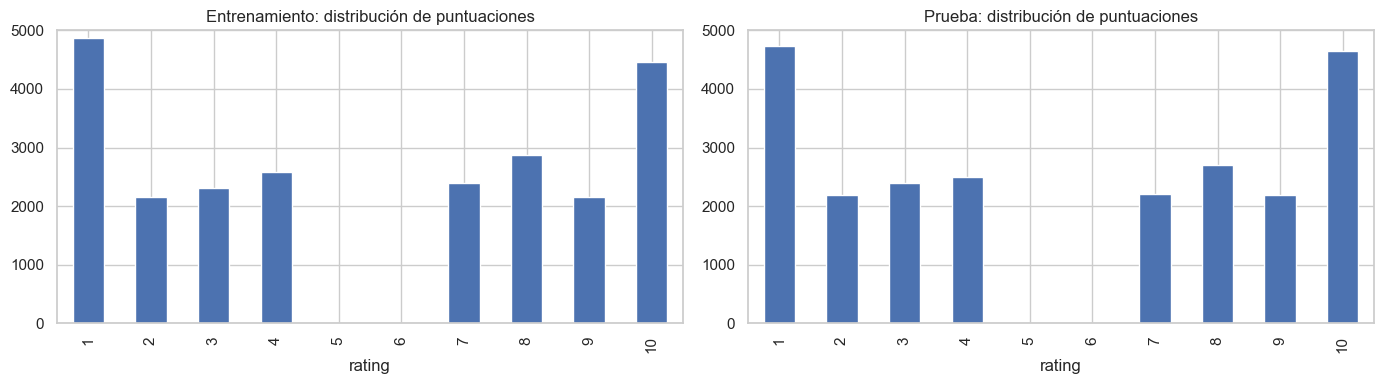

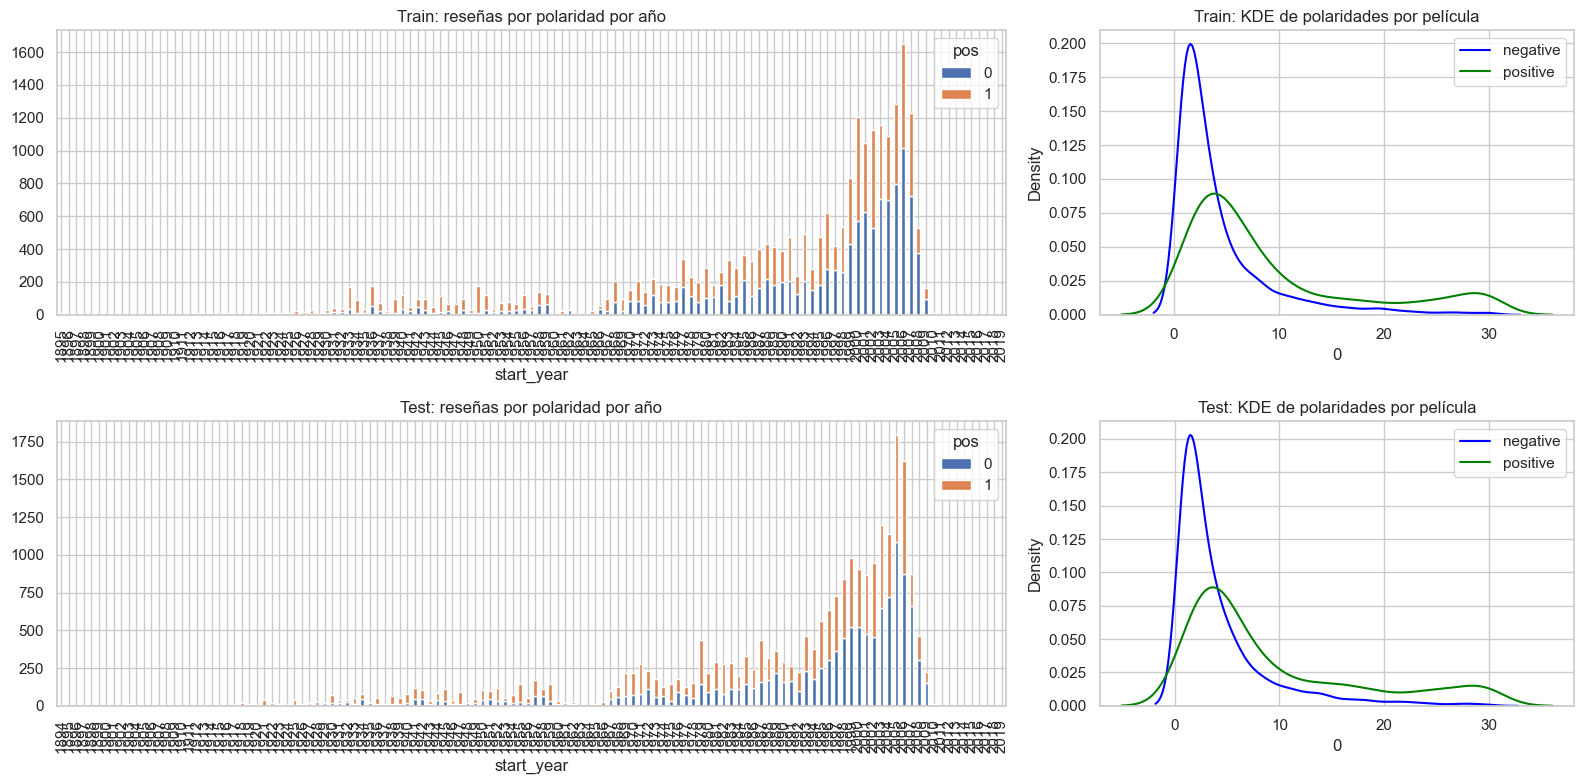

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

dft = df_reviews.groupby('tconst')['review'].count()

axs[0].bar(dft.value_counts().sort_index().index,
           dft.value_counts().sort_index().values)
axs[0].set_title('Conteo de #Reseñas por película')
axs[0].set_xlabel('# Reseñas')
axs[0].set_ylabel('Frecuencia')

sns.kdeplot(dft, ax=axs[1])
axs[1].set_title('KDE de #Reseñas por película')
axs[1].set_xlabel('# Reseñas')

fig.tight_layout()

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

ax = axs[0]
dft_train = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft_train = dft_train.reindex(index=np.arange(1, 11)).fillna(0)
dft_train.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('Entrenamiento: distribución de puntuaciones')

ax = axs[1]
dft_test = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft_test = dft_test.reindex(index=np.arange(1, 11)).fillna(0)
dft_test.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('Prueba: distribución de puntuaciones')

fig.tight_layout()

fig, axs = plt.subplots(2, 2, figsize=(16, 8),
                        gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]
dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype(int)
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Train: reseñas por polaridad por año')

ax = axs[0][1]
dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('Train: KDE de polaridades por película')

ax = axs[1][0]
dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype(int)
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('Test: reseñas por polaridad por año')

ax = axs[1][1]
dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', ax=ax)
ax.legend()
ax.set_title('Test: KDE de polaridades por película')

fig.tight_layout()


### Interpretación del análisis exploratorio

Los conjuntos de entrenamiento y prueba mantienen patrones comparables en puntuaciones y polaridad. La cantidad de reseñas por película es desigual, una característica esperable en datos de interacción real. Esta concentración no impide el entrenamiento, dado que cada reseña se clasifica de manera individual.

El equilibrio entre clases reduce el riesgo de que la exactitud o el valor F1 queden distorsionados por una clase dominante.


### Verificación de la distribución de la variable objetivo


In [8]:
df_reviews['pos'].value_counts()


pos
0    23715
1    23616
Name: count, dtype: int64

## Marco de evaluación

La función siguiente aplica el mismo criterio de medición a todos los modelos. Reporta Accuracy, F1, Average Precision y ROC AUC para entrenamiento y prueba, además de visualizar el comportamiento de F1 frente al umbral de decisión y las curvas ROC y precisión-recall.


In [9]:
import sklearn.metrics as metrics
def evaluate_model(model, train_features, train_target, test_features, test_target):

    eval_stats = {}

    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):

        eval_stats[type] = {}

        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]

        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[type]['ROC AUC'] = roc_auc

        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps

        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'Valor F1')

        ax = axs[1]
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')
        ax.set_title(f'Curva ROC')

        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)

    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))

    print(df_eval_stats)

    return


## Normalización del texto

Las reseñas se convierten a minúsculas, se eliminan caracteres no alfabéticos —conservando apóstrofos— y se normalizan los espacios. Este tratamiento reduce variaciones superficiales antes de la vectorización.


In [10]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z']", " ", text)
    text = " ".join(text.split())
    return text

df_reviews['review_norm'] = df_reviews['review'].progress_apply(normalize_text)
df_reviews[['review', 'review_norm']].head()


  0%|          | 0/47331 [00:00<?, ?it/s]

,review,review_norm
0,The pakage implies that Warren Beatty and Gold...,the pakage implies that warren beatty and gold...
1,How the hell did they get this made?! Presenti...,how the hell did they get this made presenting...
2,There is no real story the film seems more lik...,there is no real story the film seems more lik...
3,Um .... a serious film about troubled teens in...,um a serious film about troubled teens in sing...
4,I'm totally agree with GarryJohal from Singapo...,i'm totally agree with garryjohal from singapo...


La normalización genera la variable `review_norm`. Antes de continuar, conviene confirmar que el proceso no haya producido textos vacíos y que la cantidad de registros se conserve sin alteraciones.


## División entre entrenamiento y prueba

La fuente ya incluye una separación predefinida mediante `ds_part`. Se respeta esta división para mantener comparables los resultados y evitar contaminación entre ambos conjuntos.


In [11]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)


(23796, 18)
(23535, 18)


## Entrenamiento y comparación de modelos

### Modelo 0 — Clasificador constante

El clasificador constante establece una referencia mínima de rendimiento. Si los modelos entrenados no superan esta línea base, la solución no estaría capturando información útil del texto.


          train  test
Accuracy    0.5   0.5
F1          0.0   0.0
APS         0.5   0.5
ROC AUC     0.5   0.5


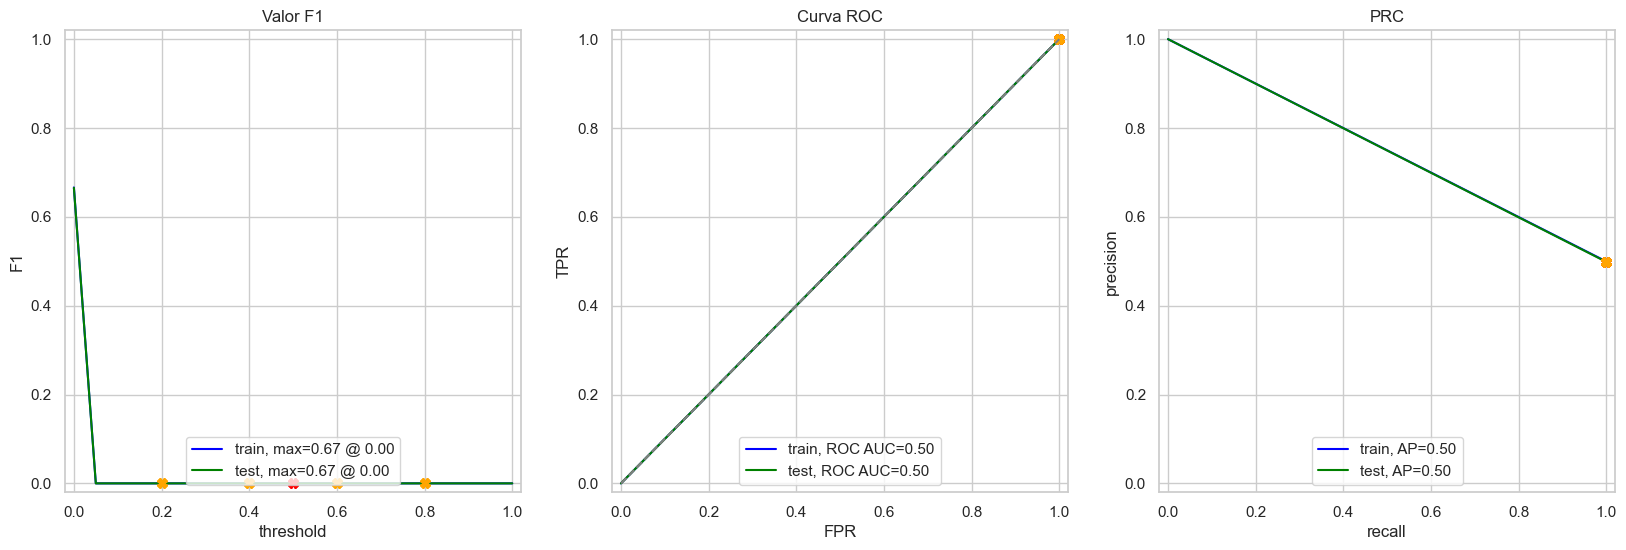

In [12]:
from sklearn.dummy import DummyClassifier

model_0 = DummyClassifier(strategy='most_frequent')
model_0.fit(np.zeros((len(train_target), 1)), train_target)

train_features_0 = np.zeros((len(train_target), 1))
test_features_0 = np.zeros((len(test_target), 1))

evaluate_model(model_0, train_features_0, train_target, test_features_0, test_target)


### Resultado de la línea base

El clasificador constante obtiene aproximadamente 0.50 de Accuracy y ROC AUC, mientras que su F1 es 0.00 porque predice únicamente la clase mayoritaria. Este resultado confirma que se necesita un modelo capaz de aprender patrones lingüísticos.


### Modelo 1 — TF-IDF y regresión logística

Las reseñas normalizadas se representan mediante TF-IDF, limitando el vocabulario a 50,000 características. La regresión logística ofrece una solución eficiente, interpretable y adecuada para matrices textuales dispersas.


In [13]:
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from nltk.corpus import stopwords


In [14]:
stop_words = stopwords.words('english')

vectorizer_1 = TfidfVectorizer(stop_words=stop_words, max_features=50000)

train_features_1 = vectorizer_1.fit_transform(df_reviews_train['review_norm'])
test_features_1 = vectorizer_1.transform(df_reviews_test['review_norm'])


Se entrena la regresión logística con un máximo de 300 iteraciones.


In [15]:
model_1 = LogisticRegression(max_iter=300)
model_1.fit(train_features_1, train_target)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Se evalúa el modelo bajo el mismo marco aplicado a la línea base.


          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


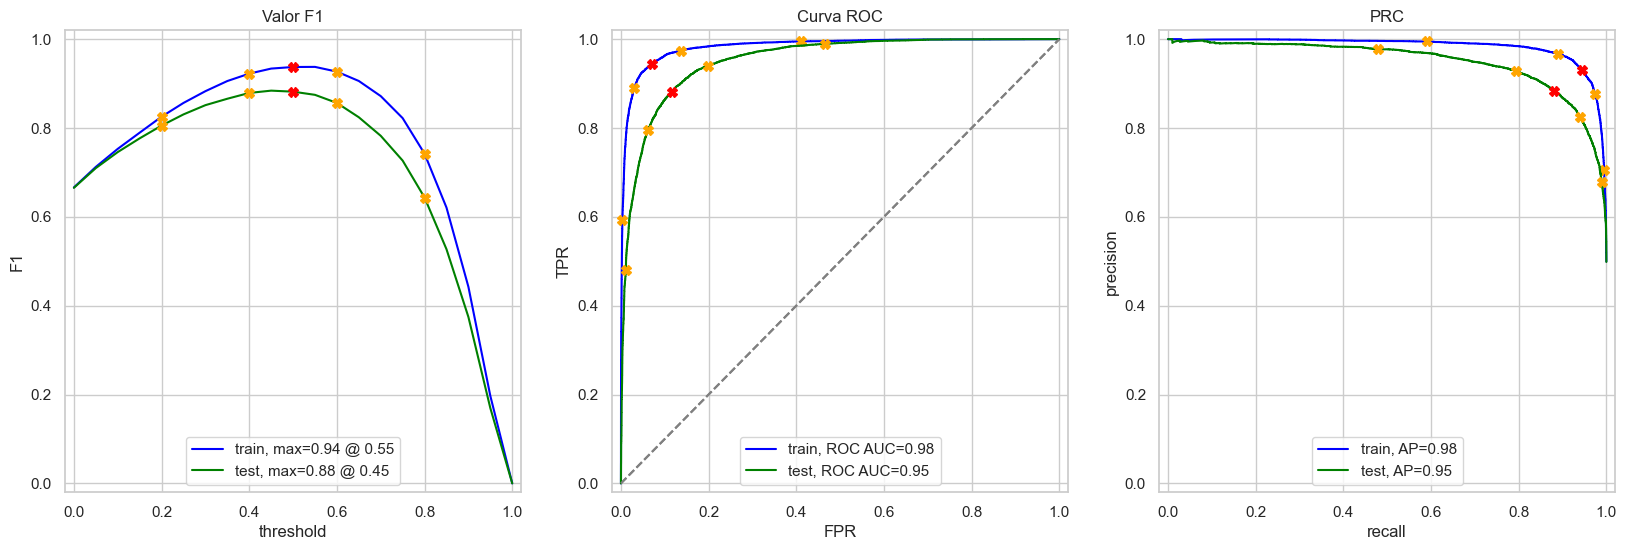

In [16]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)


### Interpretación del Modelo 1

La regresión logística alcanza un F1 de 0.94 en entrenamiento y 0.88 en prueba, además de un ROC AUC de 0.95 en prueba. Supera el criterio mínimo de F1 establecido y mantiene una diferencia moderada entre ambos conjuntos.

Su combinación de rendimiento, velocidad e interpretabilidad la convierte en una alternativa sólida para una primera implementación operativa.


### Modelo 3 — Lematización con spaCy, TF-IDF y regresión logística

Este enfoque incorpora lematización para reducir distintas formas de una palabra a una representación común. Posteriormente, el texto se vectoriza con TF-IDF y se utiliza una regresión logística.


In [17]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])


La función convierte cada reseña en una secuencia de lemas.


In [18]:
def text_preprocessing_3(text):

    doc = nlp(text)
    tokens = [token.lemma_ for token in doc]

    return ' '.join(tokens)


La lematización se aplica por separado a entrenamiento y prueba. El vectorizador se ajusta exclusivamente con los textos de entrenamiento para prevenir fuga de información.


  0%|          | 0/23796 [00:00<?, ?it/s]

  0%|          | 0/23535 [00:00<?, ?it/s]

          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


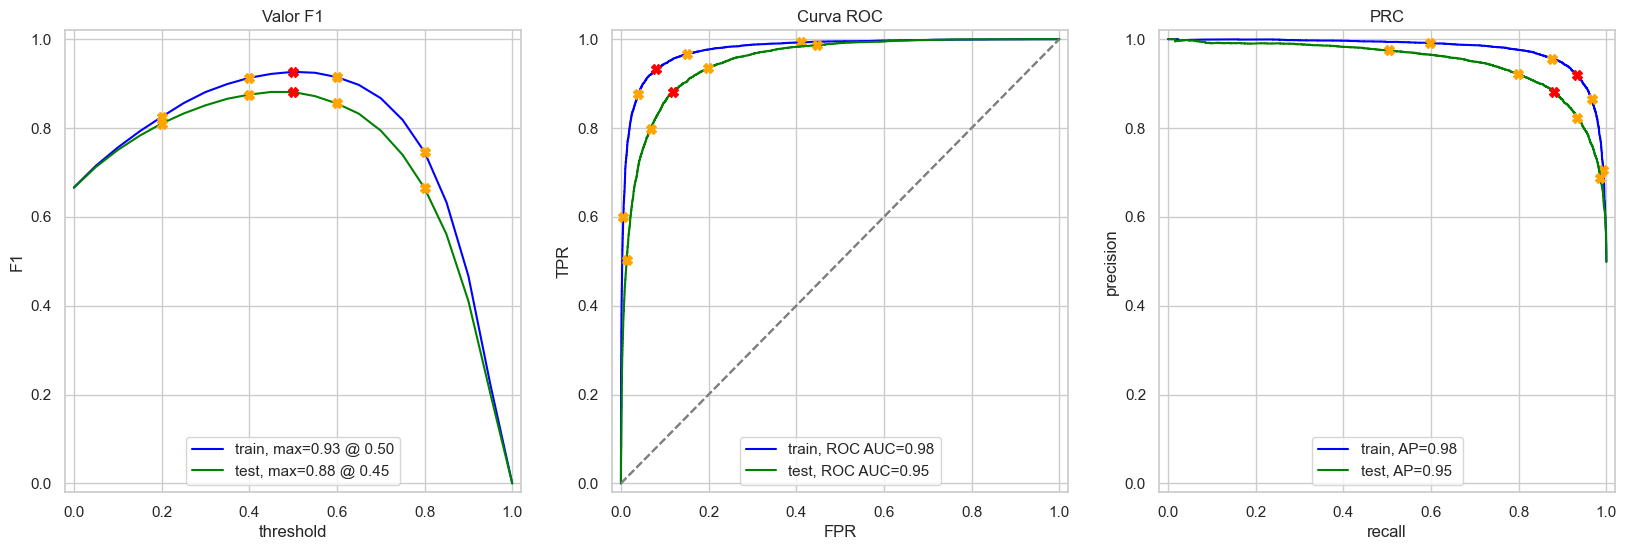

In [19]:
df_reviews_train['review_spacy'] = df_reviews_train['review_norm'].progress_apply(text_preprocessing_3)
df_reviews_test['review_spacy'] = df_reviews_test['review_norm'].progress_apply(text_preprocessing_3)

vectorizer_3 = TfidfVectorizer(max_features=50000)

train_features_3 = vectorizer_3.fit_transform(df_reviews_train['review_spacy'])
test_features_3 = vectorizer_3.transform(df_reviews_test['review_spacy'])

model_3 = LogisticRegression(max_iter=300)
model_3.fit(train_features_3, train_target)
evaluate_model(model_3, train_features_3, train_target, test_features_3, test_target)


### Interpretación del Modelo 3

El modelo con lematización obtiene un F1 cercano a 0.93 en entrenamiento y 0.88 en prueba, con un ROC AUC de aproximadamente 0.95. La lematización mantiene el rendimiento, pero no aporta una mejora material frente al Modelo 1 y aumenta el tiempo de procesamiento.


### Modelo 4 — Lematización con spaCy, TF-IDF y LightGBM

LightGBM permite evaluar si un algoritmo de boosting captura relaciones adicionales entre las características textuales.


In [20]:
from lightgbm import LGBMClassifier


Se configura el clasificador con 300 estimadores, tasa de aprendizaje de 0.1 y 31 hojas.


In [21]:
model_4 = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    num_leaves=31
)


El modelo se entrena con la representación TF-IDF del texto lematizado.


In [22]:
model_4.fit(train_features_3, train_target)


[LightGBM] [Info] Number of positive: 11884, number of negative: 11912
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.517419 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 481506
[LightGBM] [Info] Number of data points in the train set: 23796, number of used features: 9463
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499412 -> initscore=-0.002353
[LightGBM] [Info] Start training from score -0.002353


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Se calculan las métricas de entrenamiento y prueba.


          train  test
Accuracy   0.99  0.87
F1         0.99  0.87
APS        1.00  0.94
ROC AUC    1.00  0.95


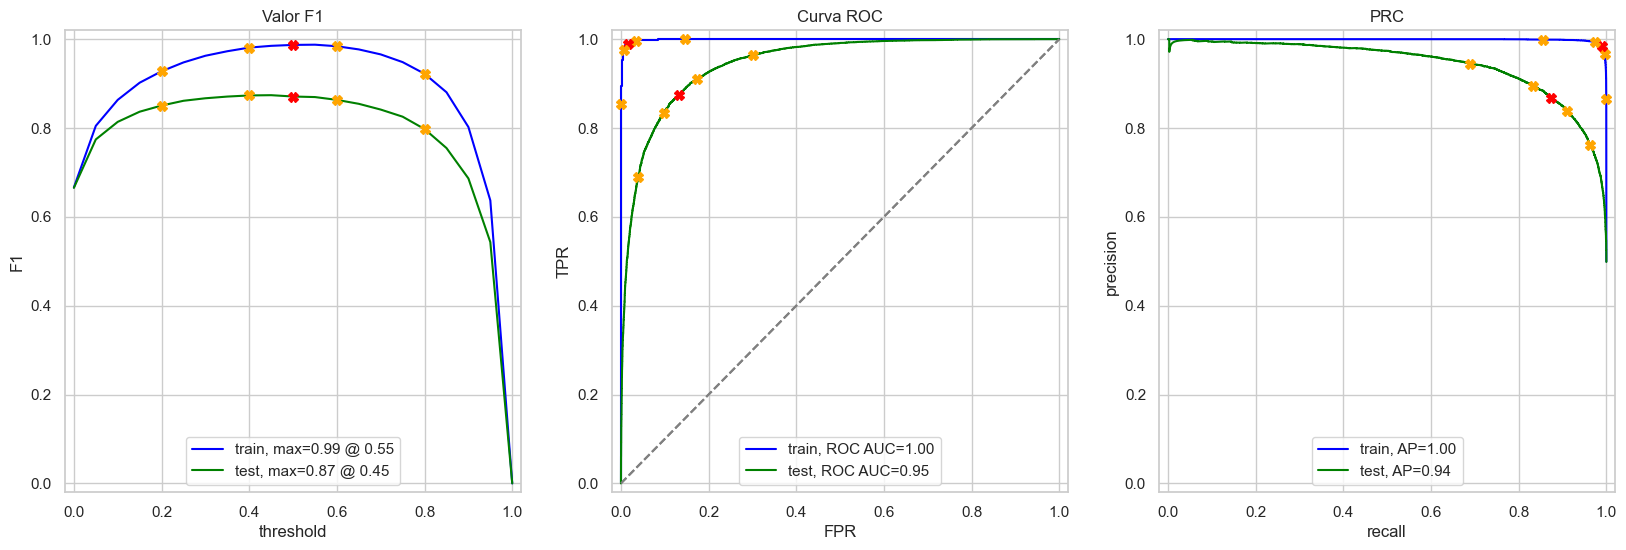

In [23]:
evaluate_model(model_4, train_features_3, train_target, test_features_3, test_target)


### Interpretación del Modelo 4

LightGBM alcanza un F1 cercano a 0.99 en entrenamiento y 0.88 en prueba, con un ROC AUC aproximado de 0.95. La diferencia entre entrenamiento y prueba evidencia mayor sobreajuste que en las regresiones logísticas, sin una mejora observable en el resultado fuera de muestra.

Desde una perspectiva operativa, la complejidad adicional no se traduce en mayor rendimiento de prueba.


### BERT — Alternativa no implementada

BERT no se entrena en este análisis debido a sus mayores requerimientos de cómputo. Los enfoques basados en TF-IDF ya superan el criterio de éxito, por lo que añadir un modelo profundo exigiría justificar el costo incremental mediante una mejora medible.


## Comparación de resultados

Los tres modelos entrenados alcanzan un F1 aproximado de 0.88 en prueba y superan el mínimo de 0.85. La regresión logística sin lematización ofrece el mejor equilibrio entre rendimiento, estabilidad y costo de procesamiento. La lematización no mejora el resultado final, mientras que LightGBM incrementa el ajuste en entrenamiento sin elevar el desempeño de prueba.


## Evaluación con reseñas adicionales

Se utilizan opiniones positivas, negativas y mixtas para observar cómo cada modelo asigna probabilidades a textos nuevos. Este ejercicio es ilustrativo y no sustituye una evaluación con datos externos etiquetados.


In [24]:
my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].apply(normalize_text)

display(my_reviews)


,review,review_norm
0,"I did not simply like it, not my kind of movie.",i did not simply like it not my kind of movie
1,"Well, I was bored and felt asleep in the middl...",well i was bored and felt asleep in the middle...
2,I was really fascinated with the movie,i was really fascinated with the movie
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...
4,I didn't expect the reboot to be so good! Writ...,i didn't expect the reboot to be so good write...
5,"The movie had its upsides and downsides, but I...",the movie had its upsides and downsides but i ...
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy not a single...
7,Launching on Netflix was a brave move & I real...,launching on netflix was a brave move i really...


### Predicciones del Modelo 1


In [25]:
texts = my_reviews['review_norm']

my_reviews_pred_prob_1 = model_1.predict_proba(vectorizer_1.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob_1[i]:.2f}:  {review}')


0.14:  i did not simply like it not my kind of movie
0.15:  well i was bored and felt asleep in the middle of the movie
0.53:  i was really fascinated with the movie
0.11:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.30:  i didn't expect the reboot to be so good writers really cared about the source material
0.47:  the movie had its upsides and downsides but i feel like overall it's a decent flick i could see myse
0.04:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.82:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


### Predicciones del Modelo 3


In [26]:
texts = my_reviews['review_norm']

texts_spacy = texts.apply(text_preprocessing_3)

my_reviews_pred_prob_3 = model_3.predict_proba(vectorizer_3.transform(texts_spacy))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob_3[i]:.2f}:  {review}')


0.16:  i did not simply like it not my kind of movie
0.22:  well i was bored and felt asleep in the middle of the movie
0.59:  i was really fascinated with the movie
0.18:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.19:  i didn't expect the reboot to be so good writers really cared about the source material
0.68:  the movie had its upsides and downsides but i feel like overall it's a decent flick i could see myse
0.03:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.87:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


### Predicciones del Modelo 4


In [27]:
texts = my_reviews['review_norm']
texts_spacy = texts.apply(text_preprocessing_3)

my_reviews_pred_prob_4 = model_4.predict_proba(vectorizer_3.transform(texts_spacy))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob_4[i]:.2f}:  {review}')


0.53:  i did not simply like it not my kind of movie
0.40:  well i was bored and felt asleep in the middle of the movie
0.57:  i was really fascinated with the movie
0.37:  even the actors looked really old and disinterested and they got paid to be in the movie what a soul
0.16:  i didn't expect the reboot to be so good writers really cared about the source material
0.82:  the movie had its upsides and downsides but i feel like overall it's a decent flick i could see myse
0.10:  what a rotten attempt at a comedy not a single joke lands everyone acts annoying and loud even kids 
0.89:  launching on netflix was a brave move i really appreciate being able to binge on episode after episo


### Interpretación cualitativa

Los modelos tienden a coincidir en opiniones claramente positivas o negativas. Las mayores diferencias aparecen en textos mixtos, donde conviven términos favorables y desfavorables.

Las regresiones logísticas producen probabilidades relativamente estables. LightGBM puede responder con mayor intensidad a combinaciones específicas de términos, aunque esa mayor complejidad no mejora su F1 de prueba. Estos ejemplos también muestran que una probabilidad alta o baja no equivale por sí sola a una medición de confianza calibrada.


## Conclusiones ejecutivas

### Resultado principal

La representación TF-IDF combinada con regresión logística alcanza un F1 aproximado de 0.88 y un ROC AUC cercano a 0.95 en prueba, superando el criterio mínimo definido.

### Modelo recomendado

El Modelo 1 —TF-IDF y regresión logística— ofrece el balance más favorable:

- Cumple el objetivo de clasificación.
- Presenta menor sobreajuste que LightGBM.
- Evita el costo adicional de la lematización.
- Facilita la interpretación y el mantenimiento del flujo analítico.

### Valor para el negocio

La clasificación automatizada puede apoyar la organización de opiniones, la detección temprana de reseñas negativas y la priorización del análisis de experiencia. No obstante, antes de utilizarla en decisiones operativas deben definirse los costos de falsos positivos y falsos negativos, ajustar el umbral de clasificación y validar el desempeño con reseñas recientes o procedentes de otros canales.

### Próximos controles recomendados

- Evaluar errores por tipo de lenguaje, longitud de reseña y presencia de negaciones.
- Verificar la calibración de las probabilidades antes de usarlas como niveles de confianza.
- Monitorear cambios en vocabulario y rendimiento a medida que ingresen nuevas reseñas.
- Comparar modelos más complejos únicamente si aportan una mejora suficiente para justificar su costo computacional.
